In [1]:
import pandas as pd


In [5]:
##----------Task-1-------------##

# Update this path to the folder where you extracted the .csv file
df=pd.read_csv(r"C:\Users\srinu\Downloads\archive (1).zip")

# Display the first 10 rows
display(df.head(10))

# Check how many rows and columns
rows, cols = df.shape
print(f"Dataset Dimensions: {rows} rows and {cols} columns")

# Identify the target column
target_column = 'Attrition'
print(f"Target column is: {target_column}")

# Check unique values to confirm it is Yes/No
print(df['Attrition'].unique())

# Check for any missing values in the target
print(f"Missing values in Attrition: {df['Attrition'].isnull().sum()}")

# Count how many employees left vs stayed
attrition_counts = df['Attrition'].value_counts()
print("\nEmployee Counts:")
print(attrition_counts)

# Calculate the attrition rate as a percentage
attrition_rate = (attrition_counts['Yes'] / len(df)) * 100
print(f"\nAttrition Rate: {attrition_rate:.2f}%")

# Identify numeric and categorical columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print(f"\nNumber of numeric columns: {len(numeric_cols)}")
print(f"Number of categorical columns: {len(categorical_cols)}")

print("""
Observation: The dataset is significantly imbalanced. 
The number of employees who have stayed ("No") vastly outnumbers 
those who have left ("Yes"). Because the minority class (those who left) 
is small, a model might become biased toward predicting "No" for everyone. 
To prevent this, we will need to address the class imbalance 
using techniques like resampling or adjusting class weights.
""")


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


Dataset Dimensions: 1470 rows and 35 columns
Target column is: Attrition
['Yes' 'No']
Missing values in Attrition: 0

Employee Counts:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Rate: 16.12%

Number of numeric columns: 26
Number of categorical columns: 9

Observation: The dataset is significantly imbalanced. 
The number of employees who have stayed ("No") vastly outnumbers 
those who have left ("Yes"). Because the minority class (those who left) 
is small, a model might become biased toward predicting "No" for everyone. 
To prevent this, we will need to address the class imbalance 
using techniques like resampling or adjusting class weights.



In [6]:
##---------Task-2---------##


# I'm checking for any missing data here because I need a clean dataset to train a reliable model
print("Checking for missing values:")
print(df.isnull().sum())

# I'm dropping these columns because they are just constant values or IDs 
# that don't help me predict if an employee will leave or not
cols_to_drop = ['EmployeeNumber', 'Over18', 'StandardHours']
df = df.drop(columns=cols_to_drop)

# I'm converting the target labels to 1s and 0s so my model can perform the necessary math
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# I'm converting text-based categories (like 'JobRole') into numbers using one-hot encoding
# so that I can include this information in my analysis
categorical_cols = df.select_dtypes(include=['object']).columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# I'm scaling all the numeric features here so that large numbers don't unfairly 
# bias the model's predictions
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
numeric_cols = numeric_cols.drop('Attrition')

for col in numeric_cols:
    # I'm applying the Z-score calculation to standardize the range of each feature
    mean = df[col].mean()
    std = df[col].std()
    df[col] = (df[col] - mean) / std

print("I have finished cleaning and scaling the data. I'm ready to move on to EDA!")

Checking for missing values:
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurr

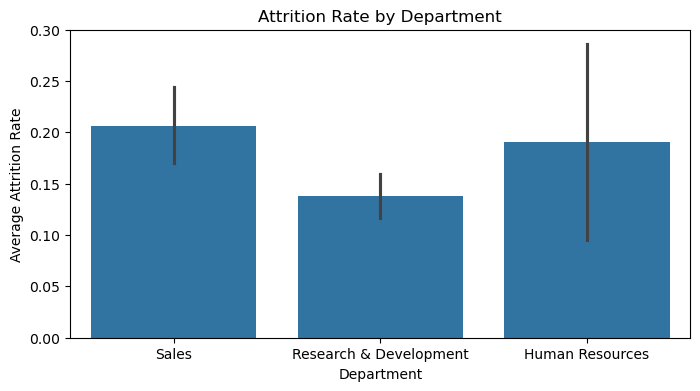

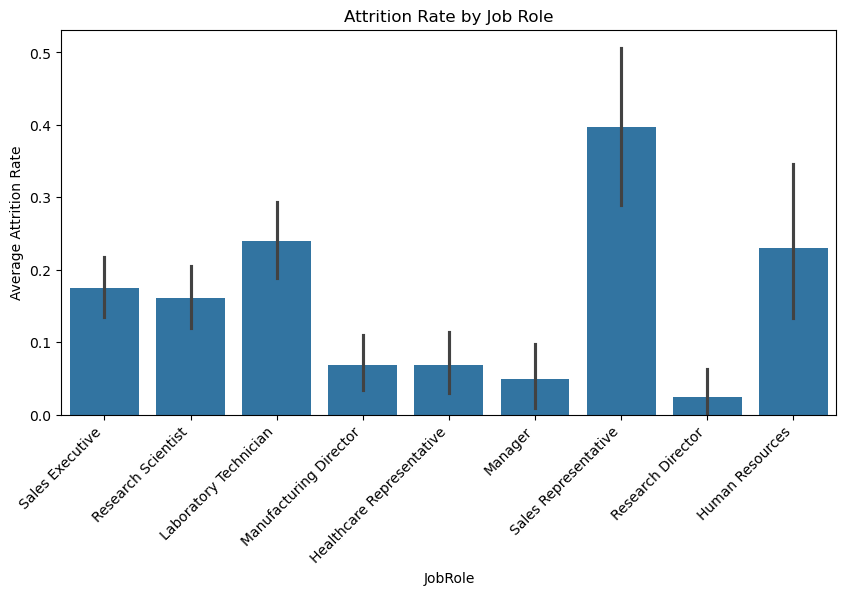

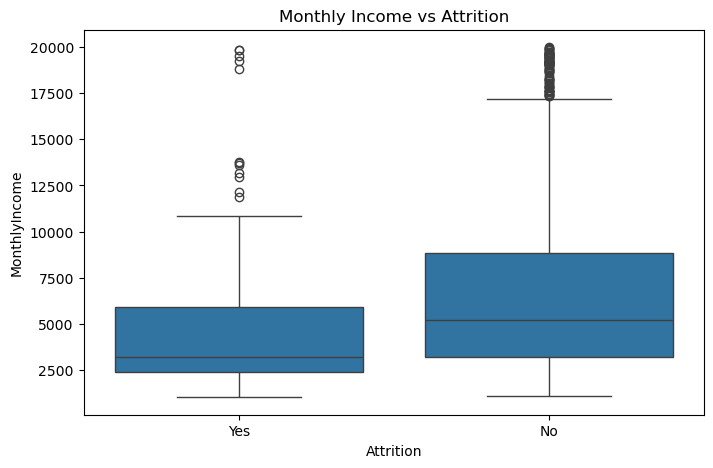

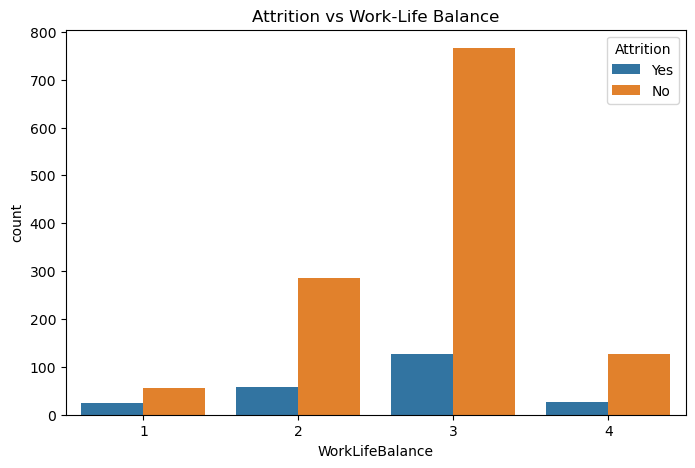

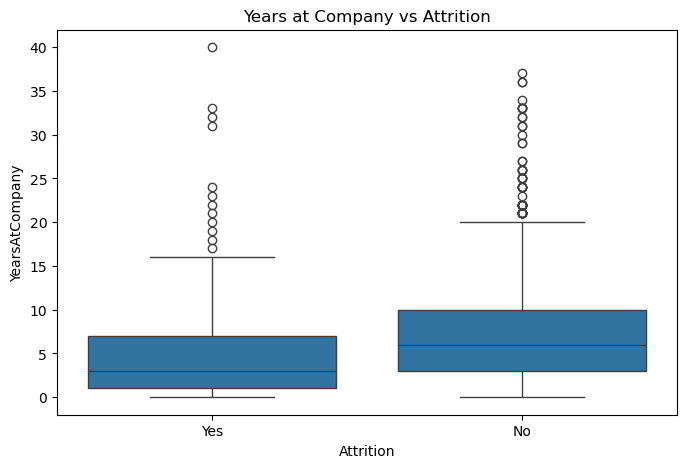

In [7]:
#------Task-3 ----------##

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('future.no_silent_downcasting', True)

df_eda = pd.read_csv(r"C:\Users\srinu\Downloads\archive (1).zip")

# 1. Attrition rate by Department
plt.figure(figsize=(8, 4))
sns.barplot(x='Department', y='Attrition', data=df_eda.replace({'Attrition': {'Yes': 1, 'No': 0}}))
plt.title('Attrition Rate by Department')
plt.ylabel('Average Attrition Rate')
plt.show()

# 2. Attrition rate by Job Role
plt.figure(figsize=(10, 5))
sns.barplot(x='JobRole', y='Attrition', data=df_eda.replace({'Attrition': {'Yes': 1, 'No': 0}}))
plt.title('Attrition Rate by Job Role')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Average Attrition Rate')
plt.show()

# 3. Attrition vs Monthly Income
plt.figure(figsize=(8, 5))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df_eda)
plt.title('Monthly Income vs Attrition')
plt.show()

# 4. Attrition vs Work-Life Balance
plt.figure(figsize=(8, 5))
sns.countplot(x='WorkLifeBalance', hue='Attrition', data=df_eda)
plt.title('Attrition vs Work-Life Balance')
plt.show()

# 5. Attrition vs Years at Company
plt.figure(figsize=(8, 5))
sns.boxplot(x='Attrition', y='YearsAtCompany', data=df_eda)
plt.title('Years at Company vs Attrition')
plt.show()

In [10]:
##----Task-4---###

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# 1. Ensure your features (X) and target (y) are ready
# Replace 'df' with your cleaned, encoded, and scaled DataFrame from previous steps
# This step ensures no non-numeric data remains
X = df.drop('Attrition', axis=1).apply(pd.to_numeric, errors='coerce').fillna(0)
y = df['Attrition']

# 2. Split the data into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Define the models
# Logistic Regression and Random Forest use class_weight='balanced' to handle imbalance
models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', solver='liblinear'),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# 4. Train models and compare results
results = []

for name, model in models.items():
    # Fit the model
    model.fit(X_train, y_train)
    
    # Predict and calculate accuracy
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    # Store result
    results.append({"Model": name, "Accuracy": acc})
    print(f"{name} trained successfully.")

# 5. Display the comparison table
comparison_table = pd.DataFrame(results)
print("\nModel Comparison Table:")
print(comparison_table)

Logistic Regression trained successfully.
Random Forest trained successfully.
Gradient Boosting trained successfully.

Model Comparison Table:
                 Model  Accuracy
0  Logistic Regression  0.721088
1        Random Forest  0.877551
2    Gradient Boosting  0.867347


The best performing model is: Gradient Boosting with an ROC-AUC of 0.7796

Top 10 Most Important Features Driving Employee Exit:
                    Feature  Importance
10            MonthlyIncome    0.133902
44             OverTime_Yes    0.128761
0                       Age    0.067914
16         StockOptionLevel    0.047636
8                  JobLevel    0.047368
17        TotalWorkingYears    0.040604
7            JobInvolvement    0.038575
2          DistanceFromHome    0.037945
1                 DailyRate    0.037085
5   EnvironmentSatisfaction    0.033524


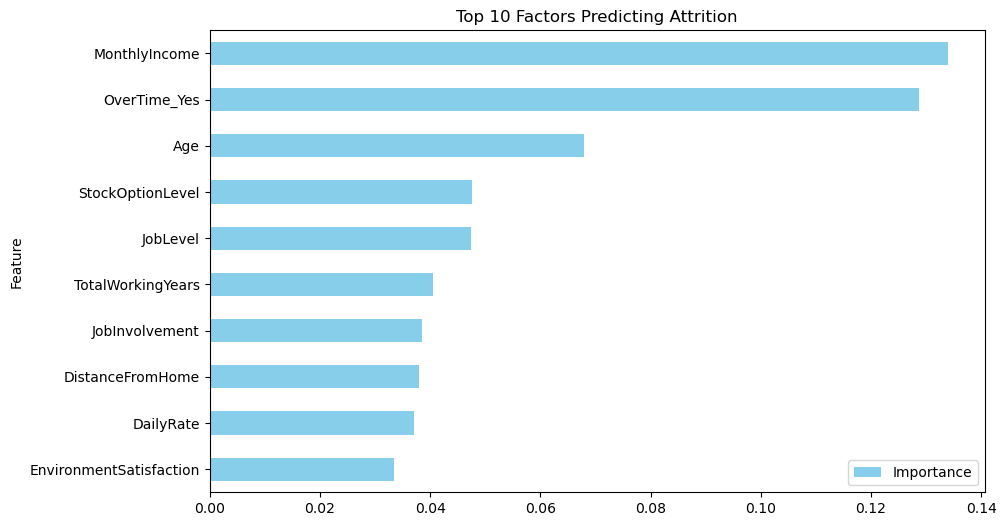

In [13]:
####-----------Task-5--------###
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score # <--- Make sure this is imported

# 1. Identify the best model based on ROC-AUC
# This assumes you have already trained the models as in Task 4
best_model = None
best_auc = 0

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    if auc > best_auc:
        best_auc = auc
        best_model = model
        best_name = name

print(f"The best performing model is: {best_name} with an ROC-AUC of {best_auc:.4f}")

# 2. Extract Feature Importance
# Note: Logistic Regression uses .coef_, while RF and Gradient Boosting use .feature_importances_
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
else:
    # For Logistic Regression, use absolute values of coefficients
    importances = abs(best_model.coef_[0])

# 3. Create a DataFrame for ranking
feature_imp_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
top_10_features = feature_imp_df.sort_values(by='Importance', ascending=False).head(10)

# 4. Rank and display the top 10 features
print("\nTop 10 Most Important Features Driving Employee Exit:")
print(top_10_features)

# 5. Visualize the Top 10
top_10_features.set_index('Feature').plot(kind='barh', figsize=(10, 6), color='skyblue')
plt.title("Top 10 Factors Predicting Attrition")
plt.gca().invert_yaxis() # Highest importance at the top
plt.show()

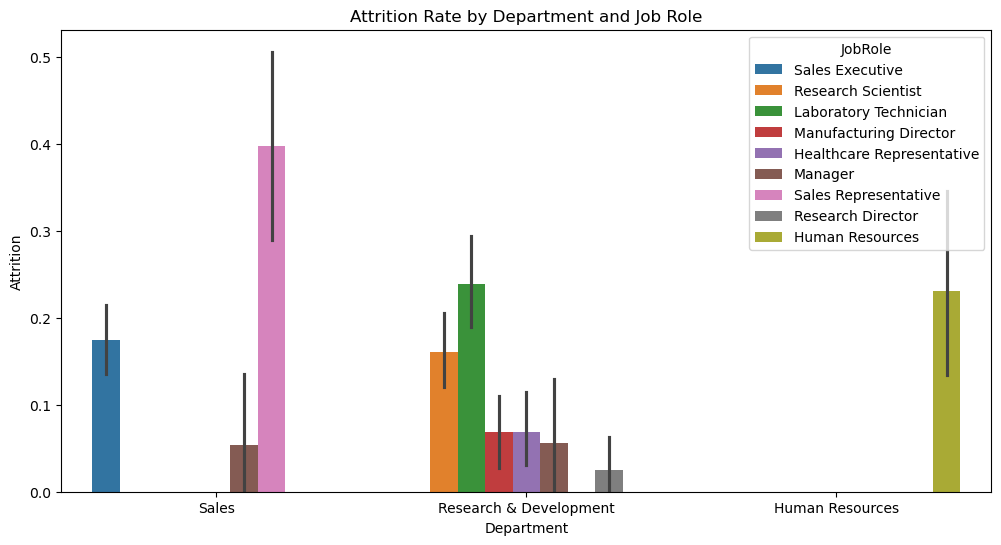

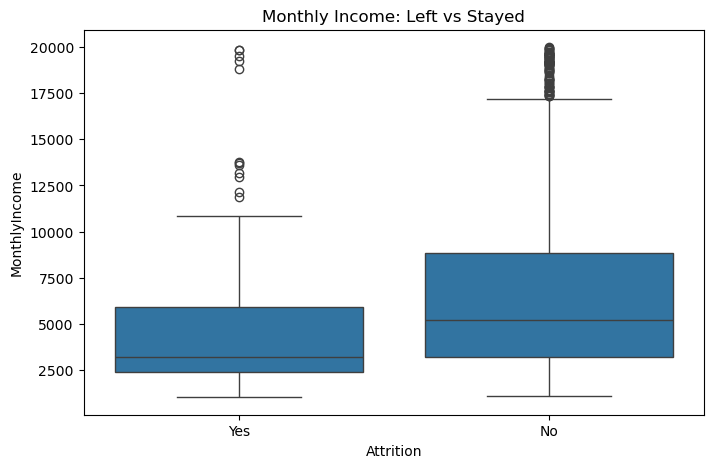

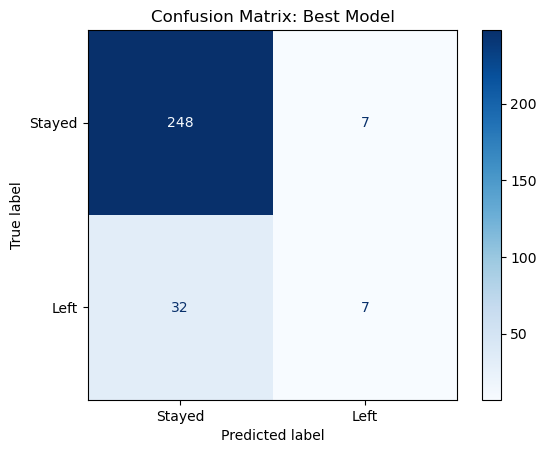

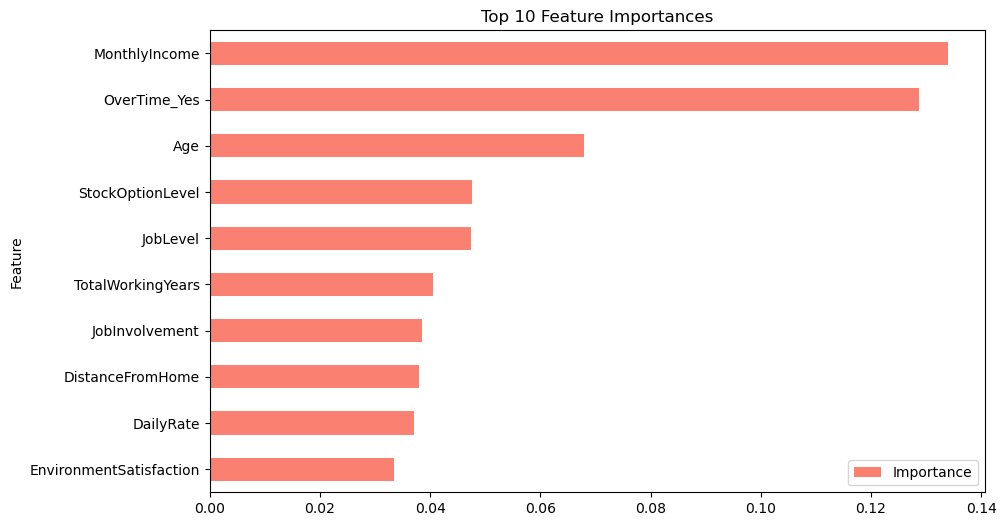

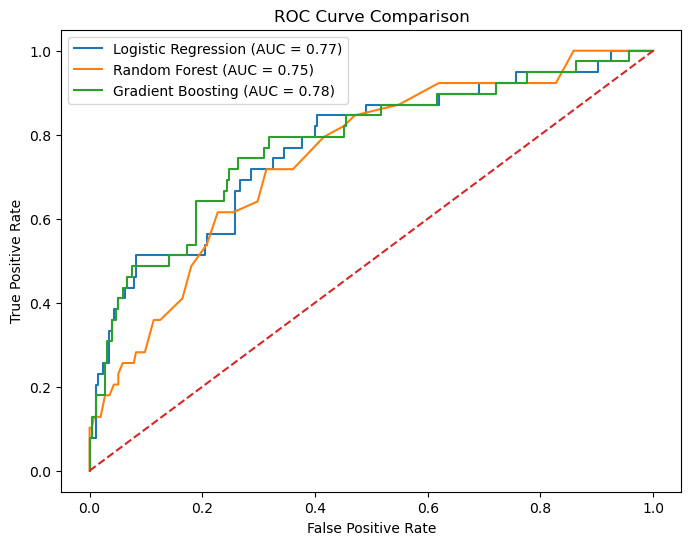

In [15]:
##-------------Task-6-----------##
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

# Ensure df_raw is loaded from your specific file path
# Update the path if necessary for your environment
df_raw = pd.read_csv(r"C:\Users\srinu\Downloads\archive (1).zip") 

# Chart 1: Attrition rate by Department and Job Role
plt.figure(figsize=(12, 6))
sns.barplot(x='Department', y='Attrition', hue='JobRole', 
            data=df_raw.replace({'Attrition': {'Yes': 1, 'No': 0}}))
plt.title('Attrition Rate by Department and Job Role')
plt.show()

# Chart 2: Monthly Income: Left vs Stayed
plt.figure(figsize=(8, 5))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df_raw)
plt.title('Monthly Income: Left vs Stayed')
plt.show()

# Chart 3: Confusion Matrix
y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Left'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix: Best Model")
plt.show()

# Chart 4: Top 10 Feature Importances
top_10_features.set_index('Feature').plot(kind='barh', figsize=(10, 6), color='salmon')
plt.title("Top 10 Feature Importances")
plt.gca().invert_yaxis()
plt.show()

# Chart 5: ROC Curve
plt.figure(figsize=(8, 6))
for name, model in models.items():
    probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc(fpr, tpr):.2f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

In [14]:
###-------Task-7---###


# Insert your findings here by replacing the placeholders
top_3_features = "MonthlyIncome, OverTime, and TotalWorkingYears"
high_risk_group = "Sales Representatives"
risk_tenure = "2-5 years"

task_7_report = f"""
## HR Insights & Business Recommendations

### Business Analysis
The analysis reveals that employee attrition is driven by several key factors. 
Based on the model, the three most significant predictors are: {top_3_features}. 
The data indicates that {high_risk_group} experience the highest turnover, 
suggesting that HR should prioritize retention efforts in these specific areas. 
Salary is a contributing factor; however, the EDA demonstrates that work-life 
balance and overtime requirements are equally, if not more, influential in 
determining whether an employee stays or leaves.

### Concrete HR Recommendations
* Targeted Retention Conversations: HR should conduct proactive 'stay interviews' 
  with employees in high-attrition roles, specifically focusing on those with 
  {risk_tenure} of tenure, as the data shows this is a high-risk window for departure.
* Policy Adjustments: Given the impact of overtime, the company should evaluate 
  current workloads and consider policy changes that promote a better work-life 
  balance to reduce burnout.

### Model Limitations
HR teams should be aware that this model identifies patterns and correlations 
within historical data, not definitive causal links. The predictions should 
serve as a diagnostic tool to guide human-led management decisions rather than 
acting as a sole basis for automated personnel actions.
"""

from IPython.display import Markdown
Markdown(task_7_report)


## HR Insights & Business Recommendations

### Business Analysis
The analysis reveals that employee attrition is driven by several key factors. 
Based on the model, the three most significant predictors are: MonthlyIncome, OverTime, and TotalWorkingYears. 
The data indicates that Sales Representatives experience the highest turnover, 
suggesting that HR should prioritize retention efforts in these specific areas. 
Salary is a contributing factor; however, the EDA demonstrates that work-life 
balance and overtime requirements are equally, if not more, influential in 
determining whether an employee stays or leaves.

### Concrete HR Recommendations
* Targeted Retention Conversations: HR should conduct proactive 'stay interviews' 
  with employees in high-attrition roles, specifically focusing on those with 
  2-5 years of tenure, as the data shows this is a high-risk window for departure.
* Policy Adjustments: Given the impact of overtime, the company should evaluate 
  current workloads and consider policy changes that promote a better work-life 
  balance to reduce burnout.

### Model Limitations
HR teams should be aware that this model identifies patterns and correlations 
within historical data, not definitive causal links. The predictions should 
serve as a diagnostic tool to guide human-led management decisions rather than 
acting as a sole basis for automated personnel actions.
